In [1]:
#

In [4]:
import pandas as pd
import os 
path_name = '/Users/yerik/_apple_lib/_a_progs/_a2ms_env/_9_ML_project/data/processed/df_03_27_2026_aiff_tracks_data.pkl'

df= pd.read_pickle(path_name)

print(len(df))
# check if paths exist 
print(df['Path'].apply(lambda x: os.path.exists(x)).all())

2402
True


In [6]:
import os

# ---------------------------------
# VARIABLE OVERVIEW + VALIDATION
# ---------------------------------

# ID
print("ID → unique identifier per track | used for joins + tracking")
print(f"Unique IDs: {df['ID'].nunique()} / {len(df)}")

# Path
paths_exist = df['Path'].apply(lambda x: os.path.exists(x))
print("\nPath → full file location | used to access and validate audio")
print(f"Files existing: {paths_exist.sum()} / {len(df)}")

# Extension
print("\nExtension → audio format (.mp3, .wav, .aiff) | used for processing consistency")
print("Extension distribution:")
print(df['Extension'].value_counts())

ID → unique identifier per track | used for joins + tracking
Unique IDs: 2402 / 2402

Path → full file location | used to access and validate audio
Files existing: 2402 / 2402

Extension → audio format (.mp3, .wav, .aiff) | used for processing consistency
Extension distribution:
Extension
.aiff    2402
Name: count, dtype: int64


dur_seconds / dur_min → track length | used for filtering + set building

Duration stats (seconds):
count     2402.000000
unique    2306.000000
top        373.333333
freq         5.000000
Name: dur_seconds, dtype: float64


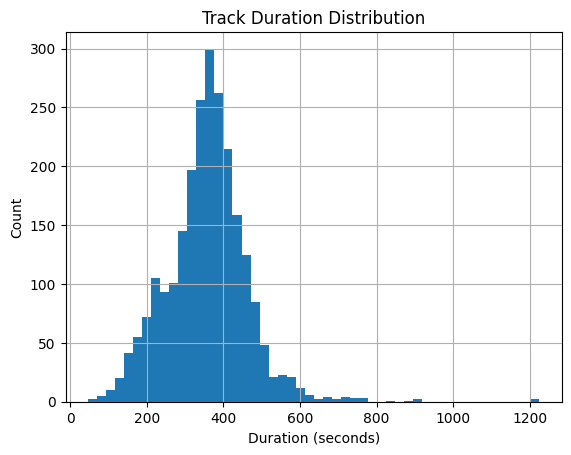


sr → sample rate (Hz) | impacts audio quality + processing

Sample Rate Distribution:
sr
44100    2402
Name: count, dtype: int64

bit_depth → audio resolution | affects dynamic range

Bit Depth Distribution:
bit_depth
16    2402
Name: count, dtype: int64


In [8]:
import matplotlib.pyplot as plt

# ---------------------------------
# AUDIO CORE FEATURES
# ---------------------------------

# Duration
print("dur_seconds / dur_min → track length | used for filtering + set building")

print("\nDuration stats (seconds):")
print(df['dur_seconds'].describe())

# Graph (distribution)
plt.figure()
df['dur_seconds'].hist(bins=50)
plt.xlabel("Duration (seconds)")
plt.ylabel("Count")
plt.title("Track Duration Distribution")
plt.show()


# ---------------------------------
# SAMPLE RATE
# ---------------------------------
print("\nsr → sample rate (Hz) | impacts audio quality + processing")

print("\nSample Rate Distribution:")
print(df['sr'].value_counts())


# ---------------------------------
# BIT DEPTH
# ---------------------------------
print("\nbit_depth → audio resolution | affects dynamic range")

print("\nBit Depth Distribution:")
print(df['bit_depth'].value_counts())


ms_lufs → perceived loudness (LUFS, negative dB scale)
Closer to 0 = louder | More negative = quieter
Used to control energy flow + smooth transitions between tracks

LUFS stats:
count    2402.000000
mean      -10.135883
std         2.035583
min       -22.143000
25%       -11.132750
50%        -9.914500
75%        -8.798000
max        -4.994000
Name: ms_lufs, dtype: float64


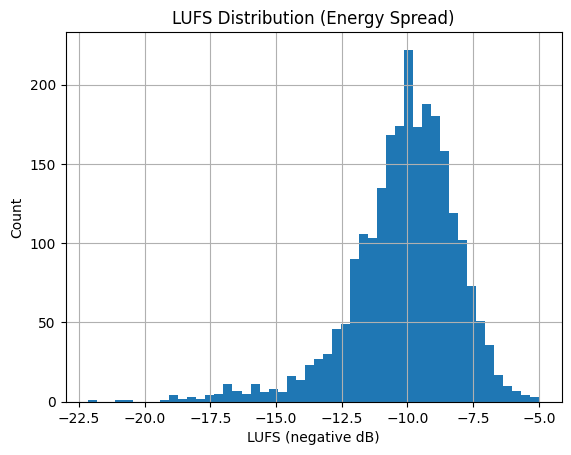


id_cat_lufs → categorical loudness bucket (A → Z)
A = quietest tracks (very negative LUFS)
Z = loudest tracks (closer to 0 LUFS)
Used to group tracks into energy pools for recommendation logic

LUFS Category Distribution:
id_cat_lufs
A      3
E      1
F      2
G      2
H      1
I      2
J      2
K      5
L      6
M     13
N     10
O     14
P     15
Q     32
R     65
S    134
T    352
U    639
V    694
W    354
X     55
Y      1
Name: count, dtype: int64


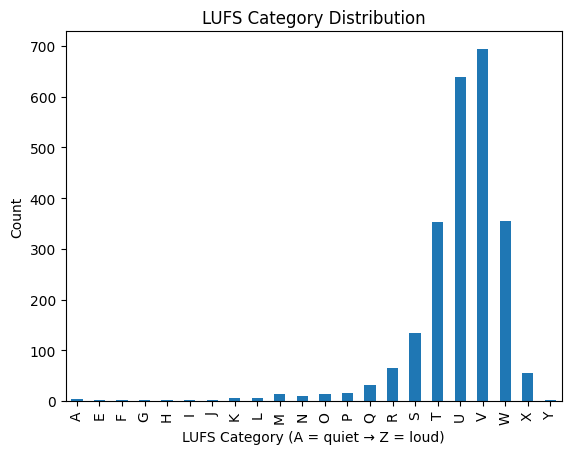

In [16]:
import matplotlib.pyplot as plt

# ---------------------------------
# LOUDNESS (LUFS)
# ---------------------------------

print("ms_lufs → perceived loudness (LUFS, negative dB scale)")
print("Closer to 0 = louder | More negative = quieter")
print("Used to control energy flow + smooth transitions between tracks")

print("\nLUFS stats:")
print(df['ms_lufs'].describe())


# ---------------------------------
# VISUAL 1 → LUFS DISTRIBUTION
# ---------------------------------
plt.figure()
df['ms_lufs'].hist(bins=50)
plt.xlabel("LUFS (negative dB)")
plt.ylabel("Count")
plt.title("LUFS Distribution (Energy Spread)")
plt.show()


# ---------------------------------
# LUFS CATEGORY (A → Z)
# ---------------------------------
print("\nid_cat_lufs → categorical loudness bucket (A → Z)")
print("A = quietest tracks (very negative LUFS)")
print("Z = loudest tracks (closer to 0 LUFS)")
print("Used to group tracks into energy pools for recommendation logic")


print("\nLUFS Category Distribution:")
print(df['id_cat_lufs'].value_counts().sort_index())


# ---------------------------------
# VISUAL 2 → CATEGORY DISTRIBUTION
# ---------------------------------
plt.figure()
df['id_cat_lufs'].value_counts().sort_index().plot(kind='bar')
plt.xlabel("LUFS Category (A = quiet → Z = loud)")
plt.ylabel("Count")
plt.title("LUFS Category Distribution")
plt.show()

mean_bpm → average tempo | main driver for matching + transitions
std_bpm → tempo variation | detects stability vs fluctuation
min_bpm / max_bpm → tempo range | identifies drift or live recordings

BPM stats:
          mean_bpm      std_bpm      min_bpm      max_bpm
count  2402.000000  2402.000000  2402.000000  2402.000000
mean    123.747459     5.072546   112.910861   133.549416
std       8.415669     7.587902    18.145565    17.612099
min      74.697720     0.000000    54.399671    74.898098
25%     120.185320     0.000000   101.332721   123.046875
50%     123.118371     0.412163   120.185320   126.048018
75%     127.457305     8.657509   126.048018   139.674831
max     169.175727    43.372622   166.708669   271.998355


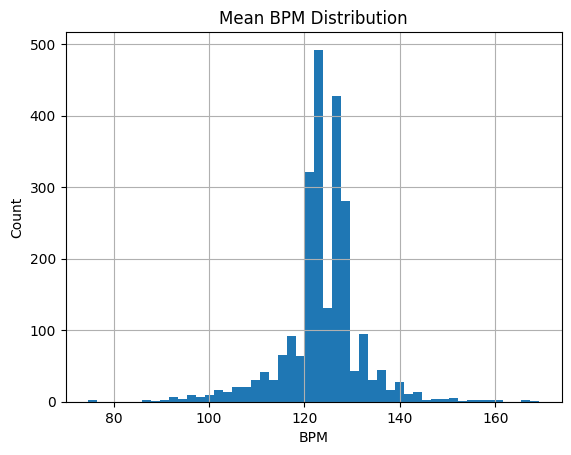


variation_percentage → relative BPM fluctuation
Low = steady (DJ-friendly) | High = dynamic / live / unstable

Variation stats:
count    2402.000000
mean        4.171160
std         6.335322
min         0.000000
25%         0.000000
50%         0.343834
75%         6.997880
max        37.343014
Name: variation_percentage, dtype: float64

dominant_bpm → most frequent tempo detected
Used as fallback when BPM fluctuates

Dominant BPM stats:
count    2402.000000
mean      123.879267
std        11.169830
min        63.000000
25%       120.000000
50%       123.000000
75%       129.000000
max       178.000000
Name: dominant_bpm, dtype: float64

bpm_consistency → stability score of tempo
Higher = more consistent → better for mixing

BPM Consistency stats:
count    2402.000000
mean       90.815282
std        15.560894
min        15.789474
25%        89.130435
50%        98.260738
75%       100.000000
max       100.000000
Name: bpm_consistency, dtype: float64

bpm_consistency_cat → categorized 

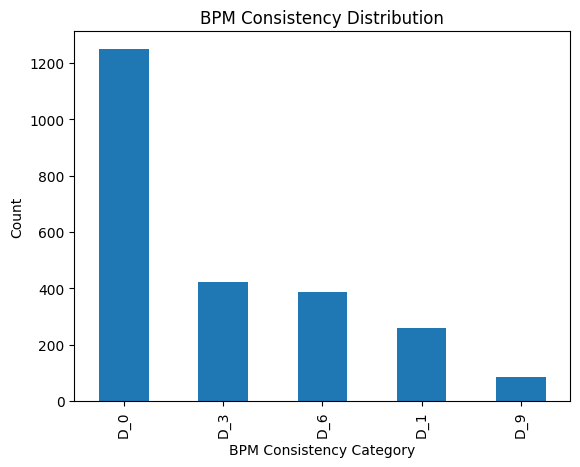

In [17]:
import matplotlib.pyplot as plt

# ---------------------------------
# BPM CORE
# ---------------------------------

print("mean_bpm → average tempo | main driver for matching + transitions")
print("std_bpm → tempo variation | detects stability vs fluctuation")
print("min_bpm / max_bpm → tempo range | identifies drift or live recordings")

print("\nBPM stats:")
print(df[['mean_bpm','std_bpm','min_bpm','max_bpm']].describe())


# ---------------------------------
# VISUAL 1 → BPM DISTRIBUTION
# ---------------------------------
plt.figure()
df['mean_bpm'].hist(bins=50)
plt.xlabel("BPM")
plt.ylabel("Count")
plt.title("Mean BPM Distribution")
plt.show()


# ---------------------------------
# VARIATION
# ---------------------------------
print("\nvariation_percentage → relative BPM fluctuation")
print("Low = steady (DJ-friendly) | High = dynamic / live / unstable")

print("\nVariation stats:")
print(df['variation_percentage'].describe())


# ---------------------------------
# DOMINANT BPM
# ---------------------------------
print("\ndominant_bpm → most frequent tempo detected")
print("Used as fallback when BPM fluctuates")

print("\nDominant BPM stats:")
print(df['dominant_bpm'].describe())


# ---------------------------------
# CONSISTENCY
# ---------------------------------
print("\nbpm_consistency → stability score of tempo")
print("Higher = more consistent → better for mixing")

print("\nBPM Consistency stats:")
print(df['bpm_consistency'].describe())


# ---------------------------------
# CATEGORY
# ---------------------------------
print("\nbpm_consistency_cat → categorized tempo stability")
print("Used to filter tracks for reliable transitions")

print("\nBPM Consistency Category Distribution:")
print(df['bpm_consistency_cat'].value_counts())


# ---------------------------------
# VISUAL 2 → CONSISTENCY CATEGORY
# ---------------------------------
plt.figure()
df['bpm_consistency_cat'].value_counts().plot(kind='bar')
plt.xlabel("BPM Consistency Category")
plt.ylabel("Count")
plt.title("BPM Consistency Distribution")
plt.show()